In [2]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader, TensorDataset
from torch_geometric.nn import MessagePassing

In [67]:
def generate_positions(n_particles=4, min_dist=0.1):
    while True:
        pos = torch.rand(n_particles, 2)

        valid = True

        for i in range(n_particles):
            for j in range(i + 1, n_particles):
                dist = torch.norm(pos[i] - pos[j])

                if dist < min_dist:
                    valid = False
                    break

            if not valid:
                break

        if valid:
            return pos

def generate_dataset(n_samples):

    X = []
    Y = []

    min_dist = 0.1

    for _ in range(n_samples):

        pos = generate_positions(n_particles=4, min_dist=min_dist)
        mass = torch.rand(4) + 0.5

        a = torch.zeros_like(pos)

        for i in range(4):
            for j in range(4):
                if i != j:
                    r = pos[j] - pos[i]
                    dist = torch.norm(r)

                    a[i] += mass[j] * r / (dist**3)

        x = torch.cat([pos.view(-1), mass])
        y = a.view(-1)

        X.append(x)
        Y.append(y)

    return torch.stack(X), torch.stack(Y)


X, Y = generate_dataset(20000)

In [68]:
perm = torch.randperm(len(X))
X, Y = X[perm], Y[perm]

split = int(0.8 * len(X))

X_train, X_val = X[:split], X[split:]
Y_train, Y_val = Y[:split], Y[split:]

Y_mean = Y_train.mean(0)
Y_std  = Y_train.std(0) + 1e-8

Y_train = (Y_train - Y_mean) / Y_std
Y_val   = (Y_val   - Y_mean) / Y_std

train_loader = DataLoader(TensorDataset(X_train, Y_train), batch_size=64, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_val, Y_val), batch_size=64)

In [69]:
def vector_to_nodes(x):
    pos = x[:, :8]
    mass = x[:, 8:]

    pos = pos.view(-1, 4, 2)
    mass = mass.view(-1, 4, 1)

    nodes = torch.cat([pos, mass], dim=2)

    return nodes

In [70]:
def make_edge_index(n_nodes=4):
    edges = []

    for i in range(n_nodes):
        for j in range(n_nodes):
            if i != j:
                edges.append([i, j])

    edge_index = torch.tensor(edges, dtype=torch.long).t()

    return edge_index

edge_index = make_edge_index(4)

print(edge_index)
print(edge_index.shape)

tensor([[0, 0, 0, 1, 1, 1, 2, 2, 2, 3, 3, 3],
        [1, 2, 3, 0, 2, 3, 0, 1, 3, 0, 1, 2]])
torch.Size([2, 12])


In [71]:
def repeat_edge_index(edge_index, batch_size, n_nodes=4):
    edge_indices = []

    for b in range(batch_size):
        offset = b * n_nodes
        edge_indices.append(edge_index + offset)

    return torch.cat(edge_indices, dim=1)

edge_index = make_edge_index(4)

xb, yb = next(iter(train_loader))

nodes = vector_to_nodes(xb)

batch_size = nodes.shape[0]

edge_index_batch = repeat_edge_index(edge_index, batch_size)

nodes_flat = nodes.view(-1, 3)

print("nodes original:", nodes.shape)
print("nodes flat:", nodes_flat.shape)
print("edge_index_batch:", edge_index_batch.shape)

nodes original: torch.Size([64, 4, 3])
nodes flat: torch.Size([256, 3])
edge_index_batch: torch.Size([2, 768])


In [72]:
class GravityLayer(MessagePassing):
    def __init__(self, hidden_dim):
        super().__init__(aggr="add")

        self.message_mlp = nn.Sequential(
            nn.Linear(6, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU()
        )

    def forward(self, x, edge_index):
        return self.propagate(edge_index, x=x)

    def message(self, x_i, x_j):
        message_input = torch.cat([x_i, x_j], dim=1)
        message = self.message_mlp(message_input)
        return message
    
class GravityGNN(nn.Module):
    def __init__(self, hidden_dim=64):
        super().__init__()

        self.gnn = GravityLayer(hidden_dim)

        self.output_mlp = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 2)
        )

    def forward(self, x):
        # x tiene forma (batch, 12)

        batch_size = x.shape[0]

        nodes = vector_to_nodes(x)

        nodes_flat = nodes.view(-1, 3)

        edge_index = make_edge_index(4).to(x.device)

        edge_index_batch = repeat_edge_index(
            edge_index,
            batch_size=batch_size,
            n_nodes=4
        ).to(x.device)

        h = self.gnn(nodes_flat, edge_index_batch)

        acc = self.output_mlp(h)

        acc = acc.view(batch_size, 8)

        return acc

In [108]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = GravityGNN(hidden_dim=64).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

n_epochs = 1000

counter = 0
patience = 100

train_losses = []
val_losses = []

for epoch in range(n_epochs):

    # ENTRENAMIENTO

    model.train()

    total_train_loss = 0

    for xb, yb in train_loader:

        xb = xb.to(device)
        yb = yb.to(device)

        pred = model(xb)

        loss = criterion(pred, yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_train_loss += loss.item() * xb.shape[0]

    train_loss = total_train_loss / len(train_loader.dataset)
    train_losses.append(train_loss)

    # VALIDACIÓN

    model.eval()

    total_val_loss = 0

    with torch.no_grad():

        for xb, yb in val_loader:

            xb = xb.to(device)
            yb = yb.to(device)

            pred = model(xb)

            loss = criterion(pred, yb)

            total_val_loss += loss.item() * xb.shape[0]

    val_loss = total_val_loss / len(val_loader.dataset)
    val_losses.append(val_loss)
    
    # CHECKPOINT 
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0

        torch.save(model.state_dict(), "best_model.pt")

    else:
        counter += 1

    # EARLY STOPPING 
    if counter >= patience:
        print("Early stopping activado")
        break

    # PRINT

    print(
        f"Epoch {epoch+1:03d} | "
        f"Train Loss: {train_loss:.6f} | "
        f"Val Loss: {val_loss:.6f}"
    )

Epoch 001 | Train Loss: 0.830191 | Val Loss: 0.667196
Epoch 002 | Train Loss: 0.519464 | Val Loss: 0.419137
Epoch 003 | Train Loss: 0.340926 | Val Loss: 0.302196
Epoch 004 | Train Loss: 0.247183 | Val Loss: 0.217843
Epoch 005 | Train Loss: 0.187449 | Val Loss: 0.172697
Epoch 006 | Train Loss: 0.153988 | Val Loss: 0.140827
Epoch 007 | Train Loss: 0.131158 | Val Loss: 0.133711
Epoch 008 | Train Loss: 0.113976 | Val Loss: 0.106793
Epoch 009 | Train Loss: 0.104162 | Val Loss: 0.100389
Epoch 010 | Train Loss: 0.094770 | Val Loss: 0.091761
Epoch 011 | Train Loss: 0.089196 | Val Loss: 0.090356
Epoch 012 | Train Loss: 0.083756 | Val Loss: 0.088427
Epoch 013 | Train Loss: 0.082111 | Val Loss: 0.074134
Epoch 014 | Train Loss: 0.073265 | Val Loss: 0.069769
Epoch 015 | Train Loss: 0.070326 | Val Loss: 0.073770
Epoch 016 | Train Loss: 0.068999 | Val Loss: 0.061383
Epoch 017 | Train Loss: 0.066464 | Val Loss: 0.060085
Epoch 018 | Train Loss: 0.062219 | Val Loss: 0.059032
Epoch 019 | Train Loss: 0.05

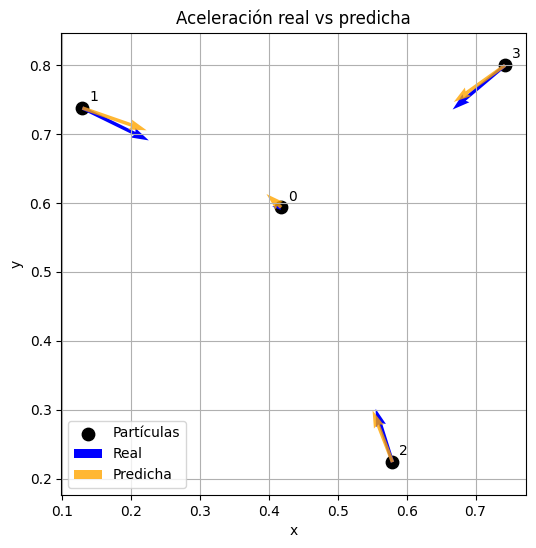

In [150]:
import random
import matplotlib.pyplot as plt
import torch

model.eval()

# Muestra aleatoria de validación
idx = random.randint(0, len(X_val) - 1)

x_sample = X_val[idx:idx+1].to(device)
y_sample = Y_val[idx:idx+1].to(device)

with torch.no_grad():
    y_pred = model(x_sample)

Y_mean_device = Y_mean.to(device)
Y_std_device  = Y_std.to(device)

y_real = y_sample * Y_std_device + Y_mean_device
y_pred_real = y_pred * Y_std_device + Y_mean_device

pos = x_sample.cpu()[0, :8].view(4, 2).numpy()

acc_real = y_real.cpu()[0].view(4, 2).numpy()
acc_pred = y_pred_real.cpu()[0].view(4, 2).numpy()

plt.figure(figsize=(6, 6))

plt.scatter(pos[:, 0], pos[:, 1], s=80, color="black", label="Partículas")

plt.quiver(
    pos[:, 0], pos[:, 1],
    acc_real[:, 0], acc_real[:, 1],
    angles="xy",
    scale_units="xy",
    scale=100,
    color="blue",
    label="Real"
)

plt.quiver(
    pos[:, 0], pos[:, 1],
    acc_pred[:, 0], acc_pred[:, 1],
    angles="xy",
    scale_units="xy",
    scale=100,
    color="orange",
    alpha=0.8,
    label="Predicha"
)

for i in range(4):
    plt.text(pos[i, 0] + 0.01, pos[i, 1] + 0.01, str(i))

plt.xlim(0, 1)
plt.ylim(0, 1)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Aceleración real vs predicha")
plt.legend()
plt.grid(True)
plt.axis("equal")
plt.show()